In [73]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample_poly
import neurokit2 as nk
from scipy.signal import find_peaks
import seaborn as sns


# Pandas display settings (optional)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)

In [74]:
# RESP FILE PATHS
RI1_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s3_6_p5_3_nRB3_20250621_125312_merged.h5"
RI2_3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s3_6_p5_3_nRB3_20250621_131158_merged.h5"
BLRI_s3_6_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s3_6_p5_3_nRB3_20250621_123634_merged.h5"
BLRI_s4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\BLRI_s4_7_p5_2_nRB3_20250621_144806_merged.h5"
RI_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI1_s4_7_p5_2_nRB3_20250621_150707_merged.h5"
RI2_4_7_h5_path = r"E:\Aim1\AIM1\Day1_new\resp_h5\RI2_s4_7_p5_2_nRB3_20250621_152519_merged.h5"

# BORIS CSVs (no comma at the end or it makes a tuple)
RI1_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s3_6_p5_3_nRB3_HEEPS.csv")
RI2_3_6_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s3_6_p_5_3_nRB3_2025062.csv")
RI1_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI1_s4_7_p5_2_nRB3_HEEPS.csv")
RI2_4_7_boris = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")

load_clean_resp_signal function for loading and preprocessing respiration data:

Reads raw resp signal and metadata from .h5

Computes original sampling rate (fs)

Applies a low-pass filter before downsampling to avoid aliasing

Downsamples the signal to your target_rate (default 100 Hz)

Applies a bandpass filter (0.1–20 Hz) with NeuroKit to clean the signal further

Creates a time vector that matches the cleaned signal length and sampling rate

This function returns:
rsp_cleaned: the cleaned, filtered, downsampled respiratory signal array

time_vector: time points corresponding to each sample in seconds

target_rate: the sampling rate after downsampling (e.g., 100 Hz)

You can then pass these outputs to functions like:
get_percent_change_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_start, sniff_end)

get_delta_resp_rate(signal=rsp_cleaned, times=time_vector, sniff_end)

In [51]:
def load_clean_resp_signal(h5_file, target_rate=100):
    """
    Loads, filters, downsamples respiration from .h5, returns cleaned signal and time vector.
    """
    try:
        with h5py.File(h5_file, 'r') as f:
            resp = f['resp'][:].flatten()
            ekg_meta = dict(f['ekg_metadata'].attrs)
        duration_sec = ekg_meta['duration_sec']
        fs = len(resp) / duration_sec
    except Exception as e:
        print(f"Error loading {h5_file}: {e}")
        return None, None, None

    # Pre-filter before downsampling
    nyquist = fs / 2
    norm_cutoff = (target_rate / 2) / nyquist
    b, a = butter(N=4, Wn=norm_cutoff, btype='low')
    filtered_resp = filtfilt(b, a, resp)

    # Downsample
    downsample_factor = int(fs // target_rate)
    downsampled = resample_poly(filtered_resp, up=1, down=downsample_factor)

    # Bandpass filter with neurokit
    rsp_cleaned = nk.signal_filter(
        downsampled,
        lowcut=0.1,
        highcut=20,
        method="butterworth",
        sampling_rate=target_rate,
        order=2
    )

    # Generate matching time vector
    time_vector = np.arange(len(rsp_cleaned)) / target_rate

    return rsp_cleaned, time_vector, target_rate


get_sniff_respiratory_rate function is good for calculating the breathing rate during a sniff bout:

It creates a mask to select the respiratory signal samples between sniff_start and sniff_end.

It uses find_peaks to detect inhalation peaks in that signal segment, with a minimum peak distance of 0.2 seconds (to avoid counting the same breath twice).

It calculates the duration of the sniff bout.

It returns the breathing rate as the number of detected peaks divided by the duration (giving rate in Hz).

A few things to watch out for:
Sampling rate consistency: Make sure the times array and the signal array are aligned and that sampling_rate matches the sampling frequency of the signal.

Peak detection threshold: You might want to tweak the distance or add a height parameter in find_peaks if you get too many or too few peaks.

Edge cases: If duration is zero or very small, it returns np.nan, which is good.



In [52]:
def get_sniff_respiratory_rate(signal, times, sniff_start, sniff_end, sampling_rate=100):
    """
    Compute breathing rate (Hz) during a sniff bout.
    """
    sniff_mask = (times >= sniff_start) & (times < sniff_end)
    signal_sniff = signal[sniff_mask]

    peaks, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.2)

    duration = sniff_end - sniff_start
    rate = len(peaks) / duration if duration > 0 else np.nan

    return rate

Explanation
Inputs: A pandas DataFrame with behavioral events and their start/stop times, behavior labels, and subject identifiers.

Process:

Convert start and stop times to float for consistency.

Sort all events chronologically.

Filter for social agent facial sniffing and fighting events.

For each sniff event, find the next fight event that occurs after sniffing ends.

Calculate the latency as the time difference between sniff end and fight start.

If no fight follows, latency is recorded as None.

Output: A DataFrame summarizing sniff times, fight start times, and latency between them.



In [75]:
def calculate_agent_sniff_to_fight_latency(df):
    # Ensure correct data types
    df['Start (s)'] = df['Start (s)'].astype(float)
    df['Stop (s)'] = df['Stop (s)'].astype(float)

    # Sort by time
    df = df.sort_values(by='Start (s)').reset_index(drop=True)

    # Agent-initiated face sniffs
    sniff_df = df[(df['Behavior'] == 'facial sniffing') & (df['Subject'] == 'social_agent')]

    # All fights (you can restrict to social_agent if needed)
    fight_df = df[df['Behavior'] == 'fighting']

    latencies = []

    for _, sniff in sniff_df.iterrows():
        sniff_start = sniff['Start (s)']
        sniff_end = sniff['Stop (s)']
        
        # Find the first fight *after* this sniff ends
        future_fights = fight_df[fight_df['Start (s)'] > sniff_end]
        
        if not future_fights.empty:
            next_fight = future_fights.iloc[0]
            latency = next_fight['Start (s)'] - sniff_end
            latencies.append({
                'Sniff Start Time (s)': sniff_start,
                'Sniff End Time (s)': sniff_end,
                'Fight Start Time (s)': next_fight['Start (s)'],
                'Latency (s)': latency
            })
        else:
            latencies.append({
                'Sniff Start Time (s)': sniff_start,
                'Sniff End Time (s)': sniff_end,
                'Fight Start Time (s)': None,
                'Latency (s)': None
            })

    return pd.DataFrame(latencies)

In [54]:
boris_df = pd.read_csv(r"E:\Aim1\AIM1\Day1_new\boris\RI2_s4_7_p5_2_nRB3_HEEPS.csv")
latency_df = calculate_agent_sniff_to_fight_latency(boris_df)
print(latency_df)

    Sniff Start Time (s)  Sniff End Time (s)  Fight Start Time (s)  \
0                  6.767               7.667                15.733   
1                 13.767              14.967                15.733   
2                 29.633              30.367                38.167   
3                 37.567              37.867                38.167   
4                 66.300              68.133               105.467   
5                 99.333             100.099               105.467   
6                104.067             105.099               105.467   
7                298.300             304.800               305.533   
8                334.867             334.933               338.633   
9                409.867             410.100               430.800   
10               454.000             454.699               454.700   
11               471.633             472.133               522.067   
12               472.367             475.033               522.067   
13               495

Explanation of get_respiratory_rate
This function calculates the change in breathing rate (in Hertz) immediately surrounding a specific sniff event.

Inputs:

signal: The respiratory signal array, typically representing breathing-related measurements over time.

times: A time vector corresponding to the signal samples.

sniff_time: The time point of interest (e.g., the moment a sniff starts or ends).

sampling_rate: How many samples per second the signal was recorded at (default 100 Hz).

window: Duration in seconds before and after the sniff time to analyze (default 2 seconds).

What it does:

Defines two time windows:

A pre-sniff window (from sniff_time - window up to sniff_time)

A post-sniff window (from sniff_time up to sniff_time + window)

Extracts the respiratory signal segments corresponding to these two windows.

Detects breathing peaks in each segment using a minimum distance between peaks to avoid counting noise or false peaks.

Calculates the breathing rate in each window as the number of detected peaks divided by the window length.

Returns the difference between the post-sniff and pre-sniff breathing rates (delta_rate), representing how much the breathing rate changed right after the sniff event.

Why it’s useful:
This measure helps quantify how sniffing behavior relates to changes in breathing dynamics, which can be important for understanding physiological or behavioral states during social interactions.

In [55]:
def get_respiratory_rate(signal, times, sniff_time, sampling_rate=100, window=2):
    """
    Compute the change in breathing rate (Hz) around a sniff_time.
    """
    # Define time windows
    pre_start = sniff_time - window
    pre_end = sniff_time
    post_start = sniff_time
    post_end = sniff_time + window

    # Create masks
    pre_mask = (times >= pre_start) & (times < pre_end)
    post_mask = (times >= post_start) & (times < post_end)

    # Get segments
    signal_pre = signal[pre_mask]
    signal_post = signal[post_mask]

    # Get rate = number of peaks / duration
    pre_peaks, _ = find_peaks(signal_pre, distance=sampling_rate*0.2)  # 200 ms min gap
    post_peaks, _ = find_peaks(signal_post, distance=sampling_rate*0.2)

    # Compute rate in Hz (peaks per sec)
    rate_pre = len(pre_peaks) / window
    rate_post = len(post_peaks) / window

    delta_rate = rate_post - rate_pre
    return delta_rate

In [56]:
def get_percent_change_resp_rate(signal, times, sniff_start, sniff_end, sampling_rate=100, baseline_window=4):
    """
    Calculate % change in breathing rate during sniff relative to baseline before sniff.
    """
    baseline_start = sniff_start - baseline_window
    baseline_end = sniff_start

    # Masks for baseline and sniff windows
    baseline_mask = (times >= baseline_start) & (times < baseline_end)
    sniff_mask = (times >= sniff_start) & (times < sniff_end)

    signal_baseline = signal[baseline_mask]
    signal_sniff = signal[sniff_mask]

    peaks_baseline, _ = find_peaks(signal_baseline, distance=sampling_rate * 0.2)
    peaks_sniff, _ = find_peaks(signal_sniff, distance=sampling_rate * 0.2)

    baseline_duration = baseline_end - baseline_start
    sniff_duration = sniff_end - sniff_start

    # Calculate rates (Hz)
    rate_baseline = len(peaks_baseline) / baseline_duration if baseline_duration > 0 else np.nan
    rate_sniff = len(peaks_sniff) / sniff_duration if sniff_duration > 0 else np.nan

    if rate_baseline == 0 or np.isnan(rate_baseline):
        return np.nan  # avoid division by zero or invalid baseline

    percent_change = ((rate_sniff - rate_baseline) / rate_baseline) * 100
    return percent_change


In [57]:
results = []

for _, row in latency_df.iterrows():
    sniff_start = row["Sniff Start Time (s)"]
    sniff_end = row["Sniff End Time (s)"]
    latency = row["Latency (s)"]

    if pd.isna(sniff_start) or pd.isna(sniff_end) or pd.isna(latency):
        continue

    pct_change = get_percent_change_resp_rate(resp_signal, times, sniff_start, sniff_end)

    results.append({
        "%Resp Rate Change": pct_change,
        "Latency (s)": latency
    })

resp_rate_df = pd.DataFrame(results)


In [58]:
# Map mouse ID → file paths
mice_data = [
    {
        "mouse_id": "RI1_s3_6",
        "h5_path": RI1_3_6_h5_path,
        "boris_df": RI1_3_6_boris
    },
    {
        "mouse_id": "RI2_s3_6",
        "h5_path": RI2_3_6_h5_path,
        "boris_df": RI2_3_6_boris
    },
    {
        "mouse_id": "RI1_s4_7",
        "h5_path": RI_4_7_h5_path,
        "boris_df": RI1_4_7_boris
    },
    {
        "mouse_id": "RI2_s4_7",
        "h5_path": RI2_4_7_h5_path,
        "boris_df": RI2_4_7_boris
    },
    # Add BLRI files here later if needed
]

combined_results = []

for mouse in mice_data:
    print(f"Processing {mouse['mouse_id']}...")
    
    # Load and clean respiration
    resp_signal, times, fs = load_clean_resp_signal(mouse["h5_path"])
    if resp_signal is None:
        continue

    # Compute sniff→fight latency
    latency_df = calculate_agent_sniff_to_fight_latency(mouse["boris_df"])
    if latency_df.empty:
        print(f"No valid sniff-fight pairs for {mouse['mouse_id']}")
        continue

    # For each sniff, calculate %Resp Rate Change and save with latency
    for _, row in latency_df.iterrows():
        sniff_start = row["Sniff Start Time (s)"]
        sniff_end = row["Sniff End Time (s)"]
        latency = row["Latency (s)"]

        if pd.isna(sniff_start) or pd.isna(sniff_end) or pd.isna(latency):
            continue

        pct_change = get_percent_change_resp_rate(resp_signal, times, sniff_start, sniff_end, sampling_rate=fs)

        combined_results.append({
            "Mouse": mouse["mouse_id"],
            "Sniff Start": sniff_start,
            "Sniff End": sniff_end,
            "Latency (s)": latency,
            "%Resp Rate Change": pct_change
        })

# Final DataFrame
all_mice_df = pd.DataFrame(combined_results)


Processing RI1_s3_6...
Processing RI2_s3_6...
Processing RI1_s4_7...
Processing RI2_s4_7...


In [59]:
all_mice_df

,Mouse,Sniff Start,Sniff End,Latency (s),%Resp Rate Change
0,RI2_s3_6,25.600,26.100,44.733,0.000000
1,RI2_s3_6,68.767,69.600,1.233,2.898302
2,RI2_s3_6,91.900,92.267,109.600,-22.148696
3,RI2_s3_6,153.900,154.400,47.467,-38.461538
4,RI2_s3_6,156.233,156.567,45.300,-7.876555
5,RI2_s3_6,195.433,195.767,6.100,99.600798
6,RI2_s3_6,196.167,197.500,4.367,15.413469
7,RI2_s3_6,218.300,219.367,0.866,15.348569
8,RI2_s3_6,226.433,226.900,0.133,-38.819211
9,RI2_s3_6,234.867,235.367,36.733,33.333333


In [69]:
print(all_mice_df.columns)


Index(['Mouse', 'Sniff Start', 'Sniff End', 'Latency (s)',
       '%Resp Rate Change'],
      dtype='object')


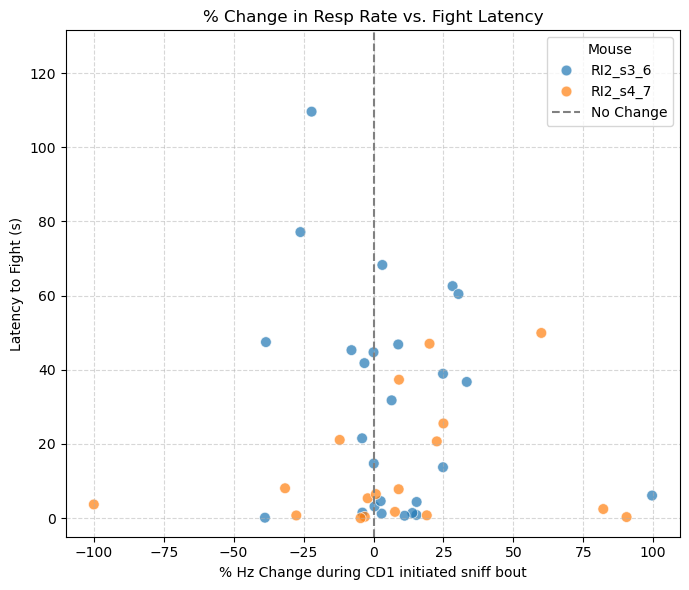

In [71]:
min_latency = -5
max_latency = all_mice_df["Latency (s)"].max()
buffer = max(5, max_latency * 0.2)

plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=all_mice_df,
    x="%Resp Rate Change",
    y="Latency (s)",
    hue="Mouse",  # <--- use 'Mouse' here
    palette="tab10",
    alpha=0.7,
    s=60
)

plt.axvline(0, linestyle='--', color='gray', label='No Change')

plt.xlabel("% Hz Change during CD1 initiated sniff bout")
plt.ylabel("Latency to Fight (s)")
plt.title("% Change in Resp Rate vs. Fight Latency")

plt.ylim(min_latency, max_latency + buffer)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Mouse")
plt.tight_layout()
plt.show()


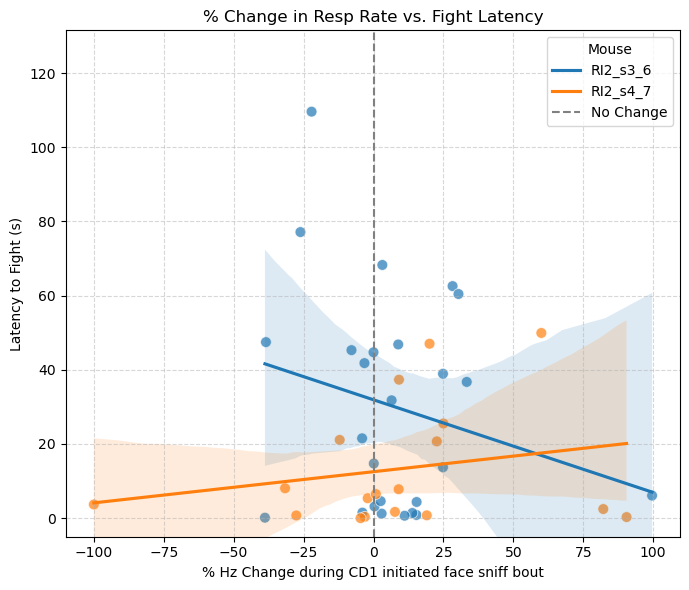

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

min_latency = -5
max_latency = all_mice_df["Latency (s)"].max()
buffer = max(5, max_latency * 0.2)

plt.figure(figsize=(7, 6))

# Scatterplot for all mice
sns.scatterplot(
    data=all_mice_df,
    x="%Resp Rate Change",
    y="Latency (s)",
    hue="Mouse",
    palette="tab10",
    alpha=0.7,
    s=60,
    legend=False  # we'll add custom legend below
)

# Add regression lines for each mouse
palette = sns.color_palette("tab10", n_colors=all_mice_df["Mouse"].nunique())
for i, (mouse, df_mouse) in enumerate(all_mice_df.groupby("Mouse")):
    df_clean = df_mouse.dropna(subset=["%Resp Rate Change", "Latency (s)"])
    if len(df_clean) > 1:
        sns.regplot(
            data=df_clean,
            x="%Resp Rate Change",
            y="Latency (s)",
            scatter=False,
            color=palette[i],
            label=f"{mouse}"
        )

plt.axvline(0, linestyle='--', color='gray', label='No Change')

plt.xlabel("% Hz Change during CD1 initiated face sniff bout")
plt.ylabel("Latency to Fight (s)")
plt.title("% Change in Resp Rate vs. Fight Latency")

plt.ylim(min_latency, max_latency + buffer)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Mouse")
plt.tight_layout()
plt.show()


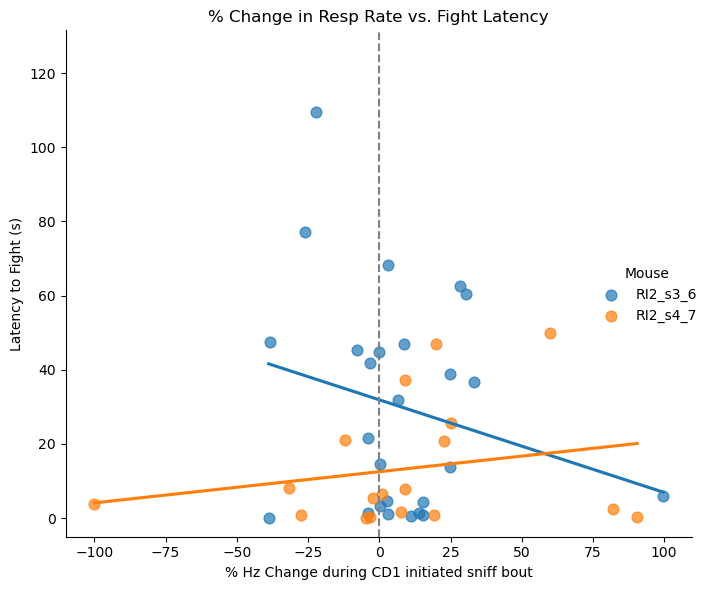

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

min_latency = -5
max_latency = all_mice_df["Latency (s)"].max()
buffer = max(5, max_latency * 0.2)

sns.lmplot(
    data=all_mice_df,
    x="%Resp Rate Change",
    y="Latency (s)",
    hue="Mouse",           # Grouping variable for separate lines
    height=6,
    aspect=1,
    markers='o',
    scatter_kws={'alpha': 0.7, 's': 60},
    ci=None  # no confidence interval bands; remove or change if you want them
)

plt.axvline(0, linestyle='--', color='gray')

plt.ylim(min_latency, max_latency + buffer)

plt.xlabel("% Hz Change during CD1 initiated sniff bout")
plt.ylabel("Latency to Fight (s)")
plt.title("% Change in Resp Rate vs. Fight Latency")

plt.tight_layout()
plt.show()


In [66]:
import pandas as pd
from scipy.stats import linregress

results = []

for mouse, df_mouse in all_mice_df.groupby("Mouse"):
    # Remove rows with missing values in the relevant columns
    df_clean = df_mouse.dropna(subset=["%Resp Rate Change", "Latency (s)"])
    
    if len(df_clean) > 1:  # Need at least 2 points for regression
        slope, intercept, r_value, p_value, std_err = linregress(
            df_clean["%Resp Rate Change"], df_clean["Latency (s)"]
        )
        results.append({
            "Mouse": mouse,
            "Slope": slope,
            "Intercept": intercept,
            "R-squared": r_value**2,
            "P-value": p_value,
            "Std Err": std_err,
            "N_points": len(df_clean)
        })
    else:
        results.append({
            "Mouse": mouse,
            "Slope": None,
            "Intercept": None,
            "R-squared": None,
            "P-value": None,
            "Std Err": None,
            "N_points": len(df_clean)
        })

stats_df = pd.DataFrame(results)
print(stats_df)


      Mouse     Slope  Intercept  R-squared   P-value   Std Err  N_points
0  RI2_s3_6 -0.249829  31.913284   0.052124  0.261956  0.217467        26
1  RI2_s4_7  0.084043  12.530740   0.047108  0.386976  0.094496        18


In [ ]:
resp_rate_df = pd.DataFrame(results)
resp_rate_df


T-statistic: 0.908
P-value: 0.3764
No significant change in breathing rate during sniff.


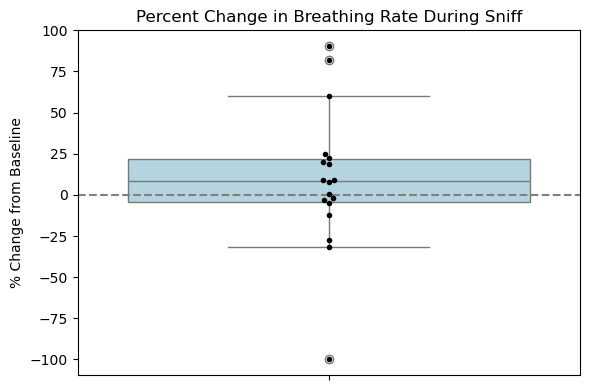

In [ ]:
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import seaborn as sns

# Drop any NaNs
cleaned = resp_rate_df.dropna(subset=["%Resp Rate Change"])

# One-sample t-test: is the % change significantly different from 0?
t_stat, p_value = ttest_1samp(cleaned["%Resp Rate Change"], 0)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

# Optional: interpret result
if p_value < 0.05:
    print("Breathing change during sniff is significantly different from baseline (p < 0.05).")
    if cleaned["%Resp Rate Change"].mean() < 0:
        print("→ Mean change is a reduction.")
    else:
        print("→ Mean change is an increase.")
else:
    print("No significant change in breathing rate during sniff.")

# Optional: Plot
plt.figure(figsize=(6, 4))
sns.boxplot(y=cleaned["%Resp Rate Change"], color="lightblue")
sns.swarmplot(y=cleaned["%Resp Rate Change"], color="black", size=4)
plt.axhline(0, color="gray", linestyle="--")
plt.title("Percent Change in Breathing Rate During Sniff")
plt.ylabel("% Change from Baseline")
plt.tight_layout()
plt.show()
